# Sarcasm Detection — Exploratory Data Analysis

Binary classification of news headlines as sarcastic or not, using the News Headlines Dataset for Sarcasm Detection (~28,600 headlines from The Onion vs HuffPost). Headlines are short and clean — no HTML or noise.

**Text column:** `headline`  |  **Label column:** `is_sarcastic`

## 1. Imports & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')
from collections import Counter
sns.set_style('whitegrid')
pd.set_option('display.max_colwidth', 120)
%matplotlib inline

In [2]:
from utils import load_data
df = load_data()
print('Shape:', df.shape)
df.head()

Shape: (28619, 2)


,headline,is_sarcastic
0,thirtysomething scientists unveil doomsday clock of hair loss,1
1,"dem rep. totally nails why congress is falling short on gender, racial equality",0
2,eat your veggies: 9 deliciously different recipes,0
3,inclement weather prevents liar from getting to work,1
4,mother comes pretty close to using word 'streaming' correctly,1


## 2. Dataset Overview

In [3]:
print('Shape:', df.shape)
print('\nColumns:', list(df.columns))
print('\nDtypes:')
print(df.dtypes)

Shape: (28619, 2)

Columns: ['headline', 'is_sarcastic']

Dtypes:
headline        object
is_sarcastic     int64
dtype: object


In [4]:
print('Duplicate rows:', df.duplicated().sum())
print('Missing per column:'); print(df.isnull().sum())

Duplicate rows: 116
Missing per column:
headline        0
is_sarcastic    0
dtype: int64


## 3. Target / Label Distribution

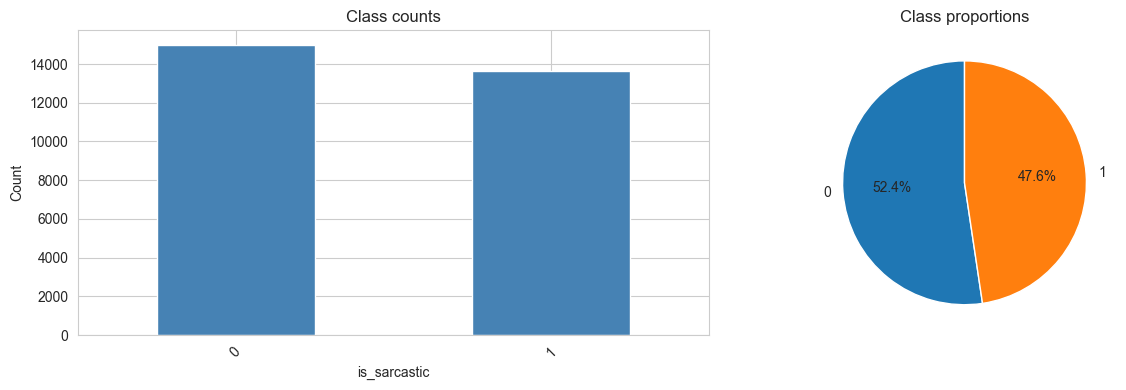

Class balance (%):
is_sarcastic
0    52.36
1    47.64
Name: count, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
counts = df['is_sarcastic'].value_counts()
counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Class counts'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
axes[1].pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class proportions')
plt.tight_layout(); plt.show()
print('Class balance (%):')
print((counts / counts.sum() * 100).round(2))

## 4. Text Length Analysis

In [6]:
df['char_count'] = df['headline'].astype(str).str.len()
df['word_count'] = df['headline'].astype(str).str.split().str.len()
df[['char_count', 'word_count']].describe().round(1)

,char_count,word_count
count,28619.0,28619.0
mean,62.3,10.0
std,20.7,3.4
min,7.0,2.0
25%,49.0,8.0
50%,62.0,10.0
75%,75.0,12.0
max,926.0,151.0


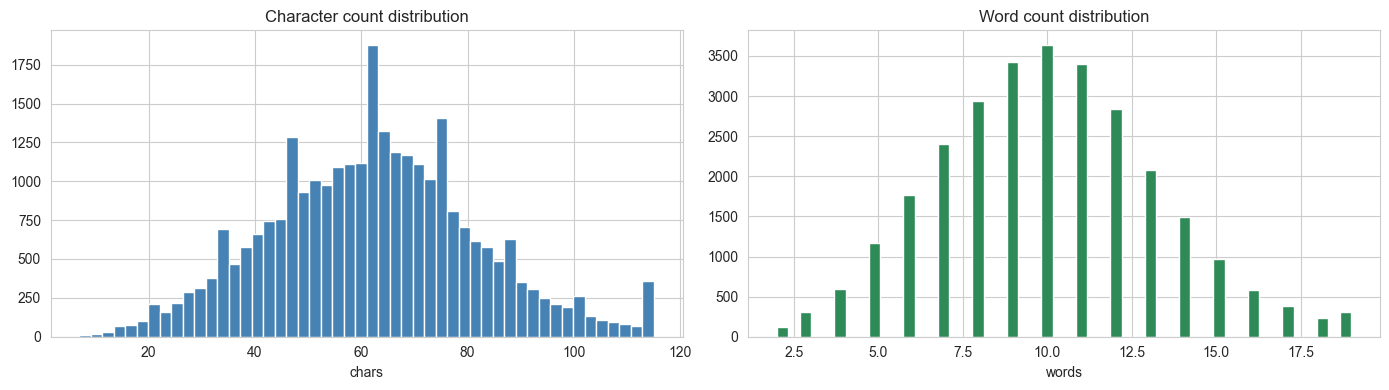

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df['char_count'].clip(upper=df['char_count'].quantile(0.99)).hist(bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Character count distribution'); axes[0].set_xlabel('chars')
df['word_count'].clip(upper=df['word_count'].quantile(0.99)).hist(bins=50, ax=axes[1], color='seagreen')
axes[1].set_title('Word count distribution'); axes[1].set_xlabel('words')
plt.tight_layout(); plt.show()

## 5. Text Length by Class

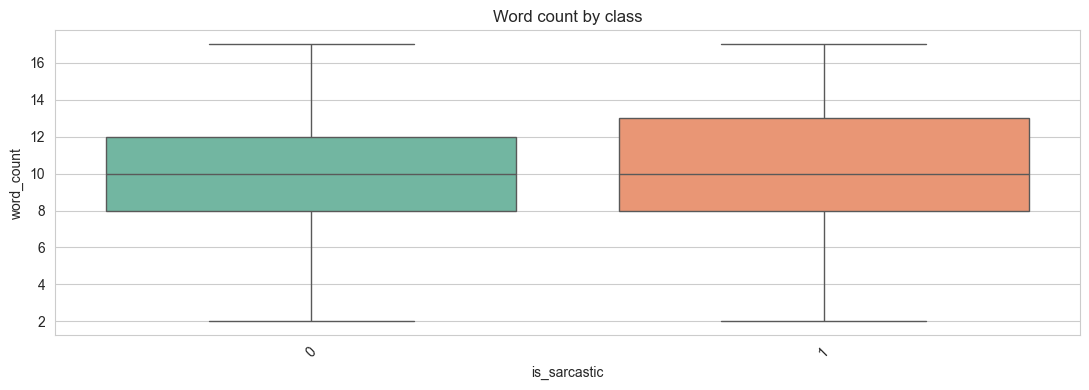

,count,mean,std,min,25%,50%,75%,max
is_sarcastic,,,,,,,,
0,14985.0,9.8,2.9,2.0,8.0,10.0,12.0,38.0
1,13634.0,10.3,3.8,2.0,8.0,10.0,13.0,151.0


In [8]:
fig, ax = plt.subplots(figsize=(11, 4))
clip_val = df['word_count'].quantile(0.97)
sns.boxplot(x='is_sarcastic', y=df['word_count'].clip(upper=clip_val), data=df, ax=ax, palette='Set2')
ax.set_title('Word count by class'); ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()
df.groupby('is_sarcastic')['word_count'].describe().round(1)

## 6. Most Frequent Words (raw, pre-cleaning)

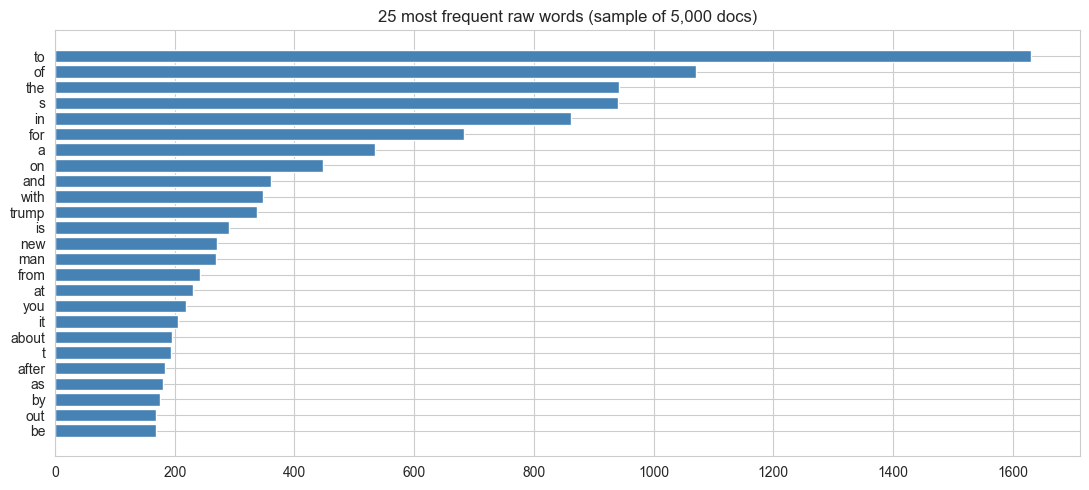

In [9]:
import re
def quick_tokens(text):
    return re.findall(r'[a-zA-Z]+', str(text).lower())
all_words = Counter()
for t in df['headline'].astype(str).sample(min(len(df), 5000), random_state=42):
    all_words.update(quick_tokens(t))
common = all_words.most_common(25)
plt.figure(figsize=(11, 5))
plt.barh([w for w, _ in common][::-1], [c for _, c in common][::-1], color='steelblue')
plt.title('25 most frequent raw words (sample of 5,000 docs)')
plt.tight_layout(); plt.show()

## 7. Word Clouds per Class

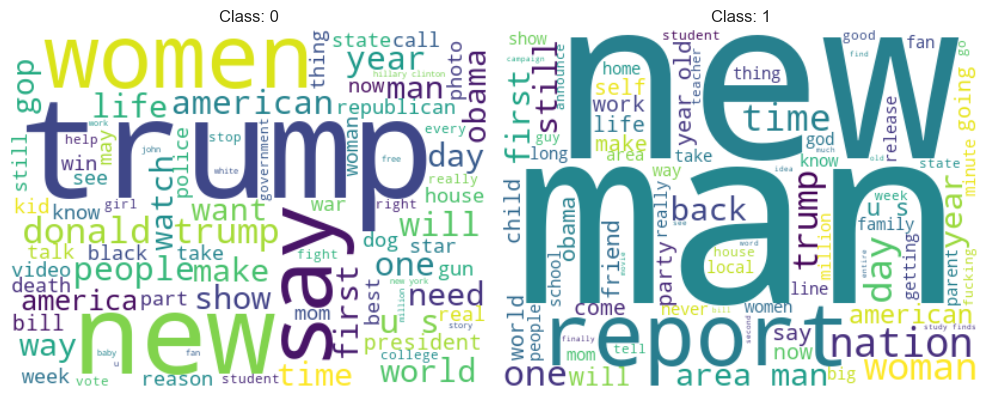

In [10]:
from wordcloud import WordCloud
classes = df['is_sarcastic'].value_counts().index.tolist()[:4]
fig, axes = plt.subplots(1, len(classes), figsize=(5*len(classes), 4))
if len(classes) == 1: axes = [axes]
for ax, cls in zip(axes, classes):
    text = ' '.join(df[df['is_sarcastic'] == cls]['headline'].astype(str).sample(min(2000, (df['is_sarcastic']==cls).sum()), random_state=42))
    wc = WordCloud(width=400, height=300, background_color='white', max_words=80).generate(text)
    ax.imshow(wc, interpolation='bilinear'); ax.axis('off'); ax.set_title(f'Class: {cls}')
plt.tight_layout(); plt.show()

## 9. Summary of Key Findings

In [11]:
summary = pd.DataFrame({
    'Metric': ['Total documents', 'Number of classes', 'Most common class',
               'Least common class', 'Mean word count', 'Median word count',
               'Max word count', 'Duplicate rows'],
    'Value': [
        len(df), df['is_sarcastic'].nunique(),
        str(df['is_sarcastic'].value_counts().idxmax()),
        str(df['is_sarcastic'].value_counts().idxmin()),
        round(df['word_count'].mean(), 1),
        int(df['word_count'].median()),
        int(df['word_count'].max()),
        int(df.duplicated().sum()),
    ],
})
summary

,Metric,Value
0,Total documents,28619
1,Number of classes,2
2,Most common class,0
3,Least common class,1
4,Mean word count,10.0
5,Median word count,10
6,Max word count,151
7,Duplicate rows,116
